# 04. DistilBERT 파인튜닝

`distilbert-base-uncased`를 Steam 리뷰 긍/부정 분류로 파인튜닝한다.

산출물: `models/distilbert/` (모델+토크나이저), `models/distilbert/metrics.json`

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.metrics import accuracy_score, f1_score
from src.config import MODEL_DIR, OUTPUT_DIR, MAX_LEN, DATA_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_MODEL = "distilbert-base-uncased"
EPOCHS = 2

/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tok = AutoTokenizer.from_pretrained(BASE_MODEL)

# 16GB 통합메모리 MPS OOM 방지: 학습은 max_length 128로 제한 (리뷰 대부분 짧음)
TRAIN_MAX_LEN = 128

def load(split):
    return Dataset.from_pandas(pd.read_csv(DATA_DIR / f"{split}.csv"))

def enc(b):
    return tok(b["text"], truncation=True, max_length=TRAIN_MAX_LEN)

ds = {s: load(s).map(enc, batched=True) for s in ["train", "val", "test"]}
print({s: len(d) for s, d in ds.items()})

Map: 100%|██████████| 2464/2464 [00:00<00:00, 10687.02 examples/s]

{'train': 11498, 'val': 2464, 'test': 2464}


In [3]:
model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2)

def metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {"accuracy": accuracy_score(p.label_ids, preds),
            "f1": f1_score(p.label_ids, preds)}

out = MODEL_DIR / "distilbert"
# 16GB 통합메모리에서 OOM 방지: 배치 8 + 누적 2 (유효 배치 16 유지)
args = TrainingArguments(
    output_dir=str(out), num_train_epochs=EPOCHS,
    per_device_train_batch_size=8, gradient_accumulation_steps=2,
    per_device_eval_batch_size=16,
    eval_strategy="epoch", save_strategy="no", report_to=[])
trainer = Trainer(model=model, args=args,
                  train_dataset=ds["train"], eval_dataset=ds["val"],
                  data_collator=DataCollatorWithPadding(tok),
                  compute_metrics=metrics)
trainer.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8433.13it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.595620,0.251043,0.898133,0.937484
2,0.427705,0.332894,0.900568,0.939611


/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=1438, training_loss=0.45430600692897577, metrics={'train_runtime': 694.1887, 'train_samples_per_second': 33.126, 'train_steps_per_second': 2.071, 'total_flos': 716683813381728.0, 'train_loss': 0.45430600692897577, 'epoch': 2.0})

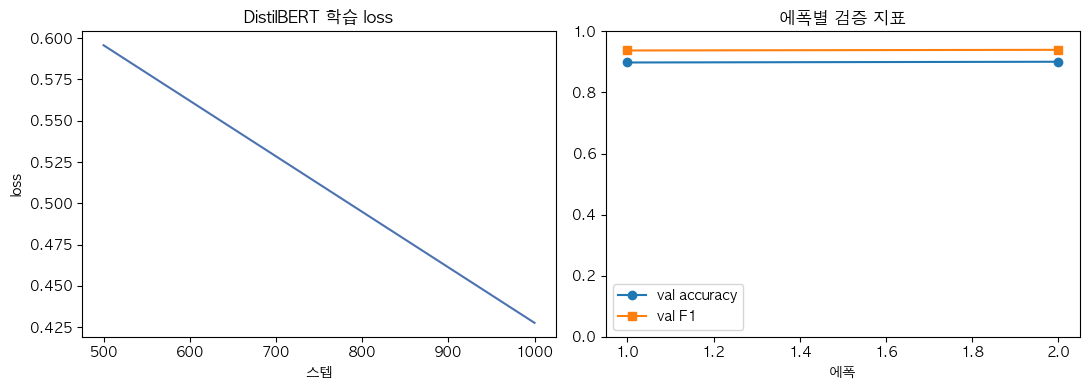

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

logs = trainer.state.log_history
train_steps = [(l["step"], l["loss"]) for l in logs if "loss" in l]
eval_logs = [l for l in logs if "eval_accuracy" in l]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(*zip(*train_steps), color="#4c72b0")
ax1.set_title("DistilBERT 학습 loss")
ax1.set_xlabel("스텝")
ax1.set_ylabel("loss")

epochs = [l["epoch"] for l in eval_logs]
ax2.plot(epochs, [l["eval_accuracy"] for l in eval_logs], "o-", label="val accuracy")
ax2.plot(epochs, [l["eval_f1"] for l in eval_logs], "s-", label="val F1")
ax2.set_title("에폭별 검증 지표")
ax2.set_xlabel("에폭")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04_distilbert_loss_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
test_metrics = trainer.evaluate(ds["test"])
out.mkdir(parents=True, exist_ok=True)
model.save_pretrained(out)
tok.save_pretrained(out)
result = {"accuracy": test_metrics["eval_accuracy"], "f1": test_metrics["eval_f1"]}
(out / "metrics.json").write_text(json.dumps(result, indent=2))
print("DistilBERT test:", result)

/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.427705,0.310980,2,0.903409,0.941466


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.71it/s]

DistilBERT test: {'accuracy': 0.9034090909090909, 'f1': 0.94146581406788}


/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


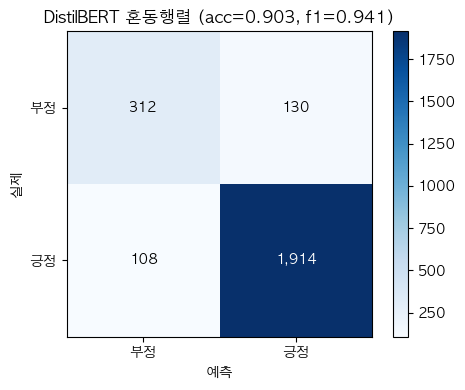

In [6]:
from sklearn.metrics import confusion_matrix

pred_out = trainer.predict(ds["test"])
preds = np.argmax(pred_out.predictions, axis=1)
cm = confusion_matrix(pred_out.label_ids, preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["부정", "긍정"])
ax.set_yticks([0, 1], ["부정", "긍정"])
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title(f"DistilBERT 혼동행렬 (acc={result['accuracy']:.3f}, f1={result['f1']:.3f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04_distilbert_confusion.png", dpi=150, bbox_inches="tight")
plt.show()